In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLO11 via Ultralytics

In [ ]:
%pip install "ultralytics<=8.3.40" supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.6/112.6 GB disk)


## Fine-tune YOLO11 on custom dataset

In [ ]:
!pip install ultralytics
!pip install roboflow

!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

rf = Roboflow(api_key="3qduNDzsBSXEa73QGWfB")
project = rf.workspace("hailhydra").project("bd-road-sign-dataset-creation-pznqx")
version = project.version(1)
dataset = version.download("yolov11")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BD-Road-Sign-Dataset-Creation-1 in yolov11:: 100%|██████████| 1904/1904 [00:00<00:00, 5433.88it/s]


/content


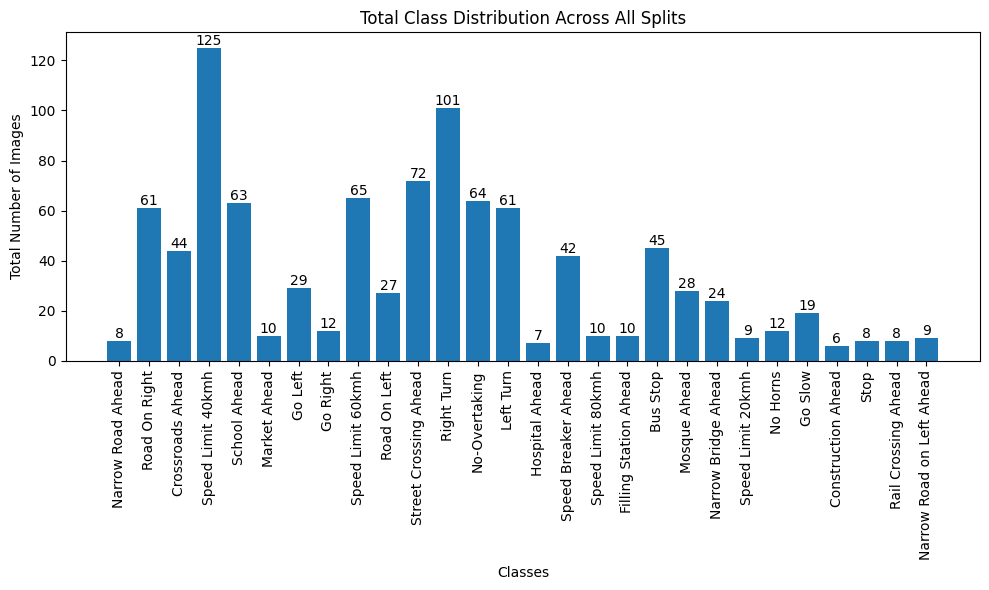

In [ ]:
import os
import matplotlib.pyplot as plt
import yaml

%cd {HOME}

# Define paths for the dataset
dataset_splits = ["train", "valid", "test"]
class_counts_per_split = {}

# Count occurrences of each class in all splits
for split in dataset_splits:
    label_folder = os.path.join(dataset.location, split, "labels")
    class_counts = {}
    for filename in os.listdir(label_folder):
        with open(os.path.join(label_folder, filename), 'r') as f:
            for line in f:
                class_id = int(line.split()[0])
                if class_id not in class_counts:
                    class_counts[class_id] = 0
                class_counts[class_id] += 1
    class_counts_per_split[split] = class_counts

# Load class names from data.yaml
with open(f'{dataset.location}/data.yaml', 'r') as f:
    data = yaml.safe_load(f)
class_names = data['names']

# Aggregate class counts across all splits
total_class_counts = {class_id: 0 for class_id in class_counts_per_split["train"].keys()}
for split in dataset_splits:
    for class_id, count in class_counts_per_split[split].items():
        total_class_counts[class_id] += count

# Create a bar chart to show the total distribution of classes across all splits
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(total_class_counts)), list(total_class_counts.values()))
plt.xticks(range(len(total_class_counts)), [class_names[i] for i in total_class_counts.keys()], rotation=90)
plt.xlabel("Classes")
plt.ylabel("Total Number of Images")
plt.title("Total Class Distribution Across All Splits")

# Add text annotations on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()


/content
Class               Train          Valid          Test           
-----------------------------------------------------------------
Narrow Road Ahead   7              0              1              
Road On Right       57             2              2              
Crossroads Ahead    42             2              0              
Speed Limit 40kmh   114            7              4              
School Ahead        54             6              3              
Market Ahead        10             0              0              
Go Left             23             2              4              
Go Right            12             0              0              
Speed Limit 60kmh   60             3              2              
Road On Left        23             1              3              
Street Crossing Ahead66             4              2              
Right Turn          93             4              4              
No-Overtaking       57             3              4              


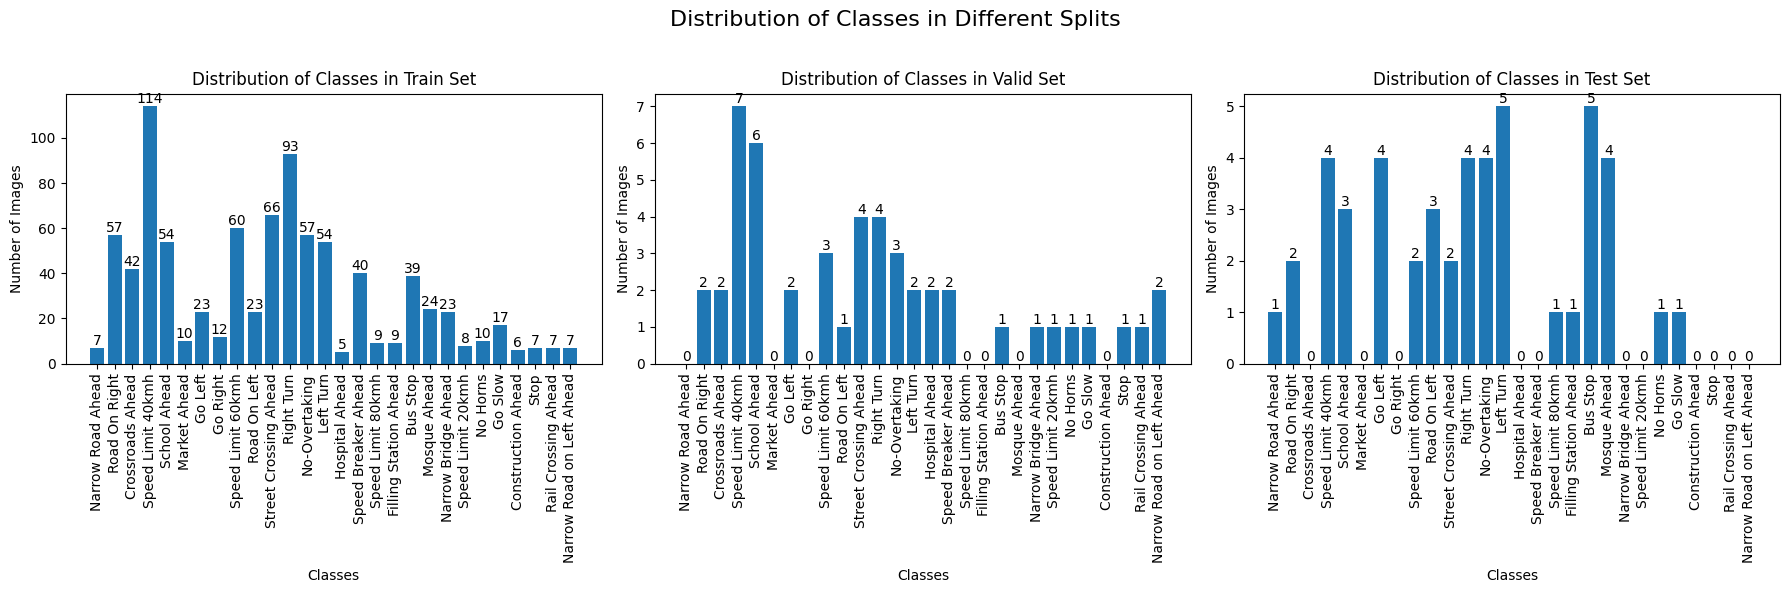

In [ ]:
import os
import matplotlib.pyplot as plt
import yaml
from collections import OrderedDict
import matplotlib.image as mpimg
import numpy as np

%cd {HOME}

def count_classes(folder):
    """Counts the occurrences of each class in a dataset folder."""
    label_folder = os.path.join(folder, "labels")
    class_counts = {}
    for filename in os.listdir(label_folder):
        with open(os.path.join(label_folder, filename), 'r') as f:
            for line in f:
                class_id = int(line.split()[0])
                if class_id not in class_counts:
                    class_counts[class_id] = 0
                class_counts[class_id] += 1
    return class_counts

# Assuming 'dataset.location' is defined and holds the base directory of the dataset
dataset_splits = ["train", "valid", "test"]
class_counts_per_split = {}

for split in dataset_splits:
    folder = os.path.join(dataset.location, split)
    class_counts_per_split[split] = count_classes(folder)

# Load class names from data.yaml
with open(f'{dataset.location}/data.yaml', 'r') as f:
    data = yaml.safe_load(f)
class_names = data['names']

# Print class counts side by side
# Create an ordered set of all classes in all splits to have a common order and make sure all classes are displayed
all_classes = OrderedDict()
for split in dataset_splits:
    for class_id in class_counts_per_split[split].keys():
        if class_id not in all_classes:
             all_classes[class_id] = None

# Print header with split names
header = "Class".ljust(20)
for split in dataset_splits:
    header += f"{split.capitalize()}".ljust(15)
print(header)
print("-" * len(header))

for class_id in all_classes.keys():
    line = class_names[class_id].ljust(20)
    for split in dataset_splits:
        count = class_counts_per_split[split].get(class_id, 0)
        line += f"{count}".ljust(15)
    print(line)
print()

# Create bar charts for each split side by side
fig_bars, axes_bars = plt.subplots(1, len(dataset_splits), figsize=(6 * len(dataset_splits), 6))
fig_bars.suptitle("Distribution of Classes in Different Splits\n", fontsize=16)

for i, split in enumerate(dataset_splits):
    class_counts = class_counts_per_split[split]
    ax = axes_bars[i] if len(dataset_splits) > 1 else axes_bars

    # Use all_classes keys to order the bars
    ordered_class_ids = list(all_classes.keys())
    ordered_counts = [class_counts.get(class_id, 0) for class_id in ordered_class_ids]

    bars = ax.bar(range(len(ordered_class_ids)), ordered_counts)
    ax.set_xticks(range(len(ordered_class_ids)))
    ax.set_xticklabels([class_names[i] for i in ordered_class_ids], rotation=90)
    ax.set_xlabel("Classes")
    ax.set_ylabel("Number of Images")
    ax.set_title(f"Distribution of Classes in {split.capitalize()} Set")

    # Add text annotations on top of each bar
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

## Custom Training

In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml epochs=20 imgsz=640 plots=True

/content
100% 5.35M/5.35M [00:00<00:00, 115MB/s]
New https://pypi.org/project/ultralytics/8.3.146 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/datasets/BD-Road-Sign-Dataset-Creation-1/data.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnosti

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml					    train_batch0.jpg
confusion_matrix_normalized.png			    train_batch1.jpg
confusion_matrix.png				    train_batch2.jpg
events.out.tfevents.1748552983.74384ca20585.1015.0  train_batch540.jpg
F1_curve.png					    train_batch541.jpg
labels_correlogram.jpg				    train_batch542.jpg
labels.jpg					    val_batch0_labels.jpg
P_curve.png					    val_batch0_pred.jpg
PR_curve.png					    val_batch1_labels.jpg
R_curve.png					    val_batch1_pred.jpg
results.csv					    weights
results.png


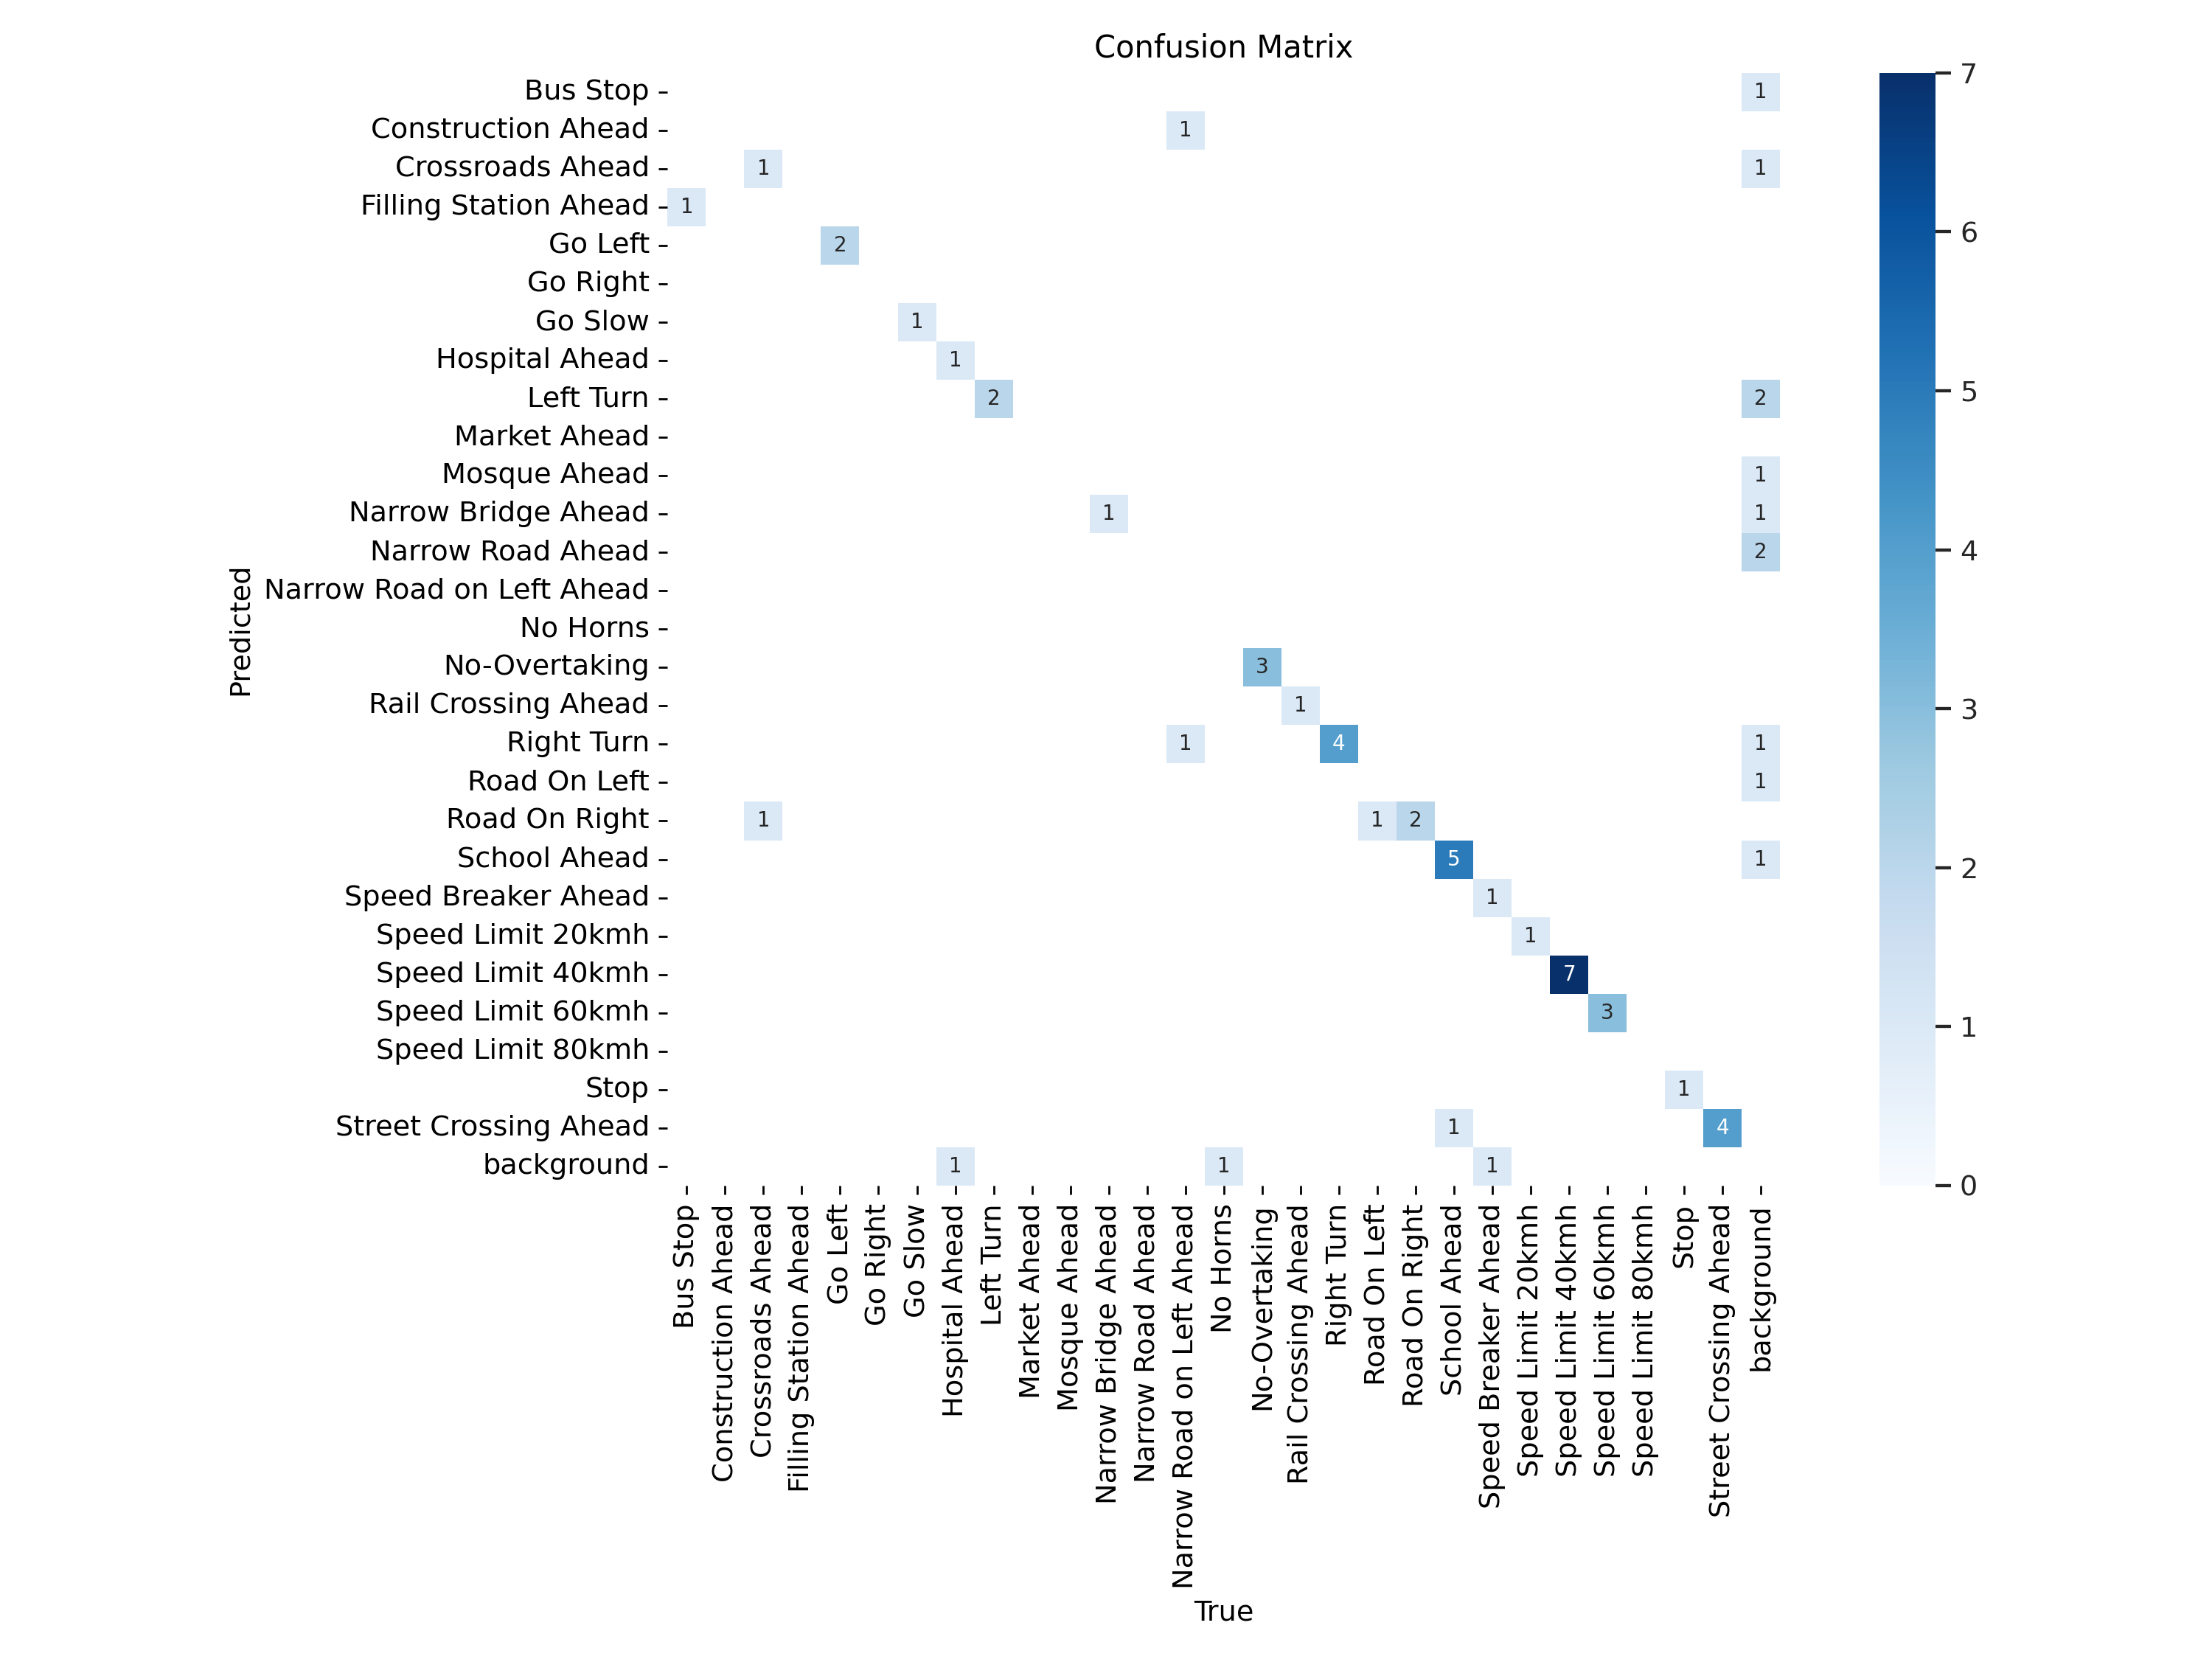

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=1000)

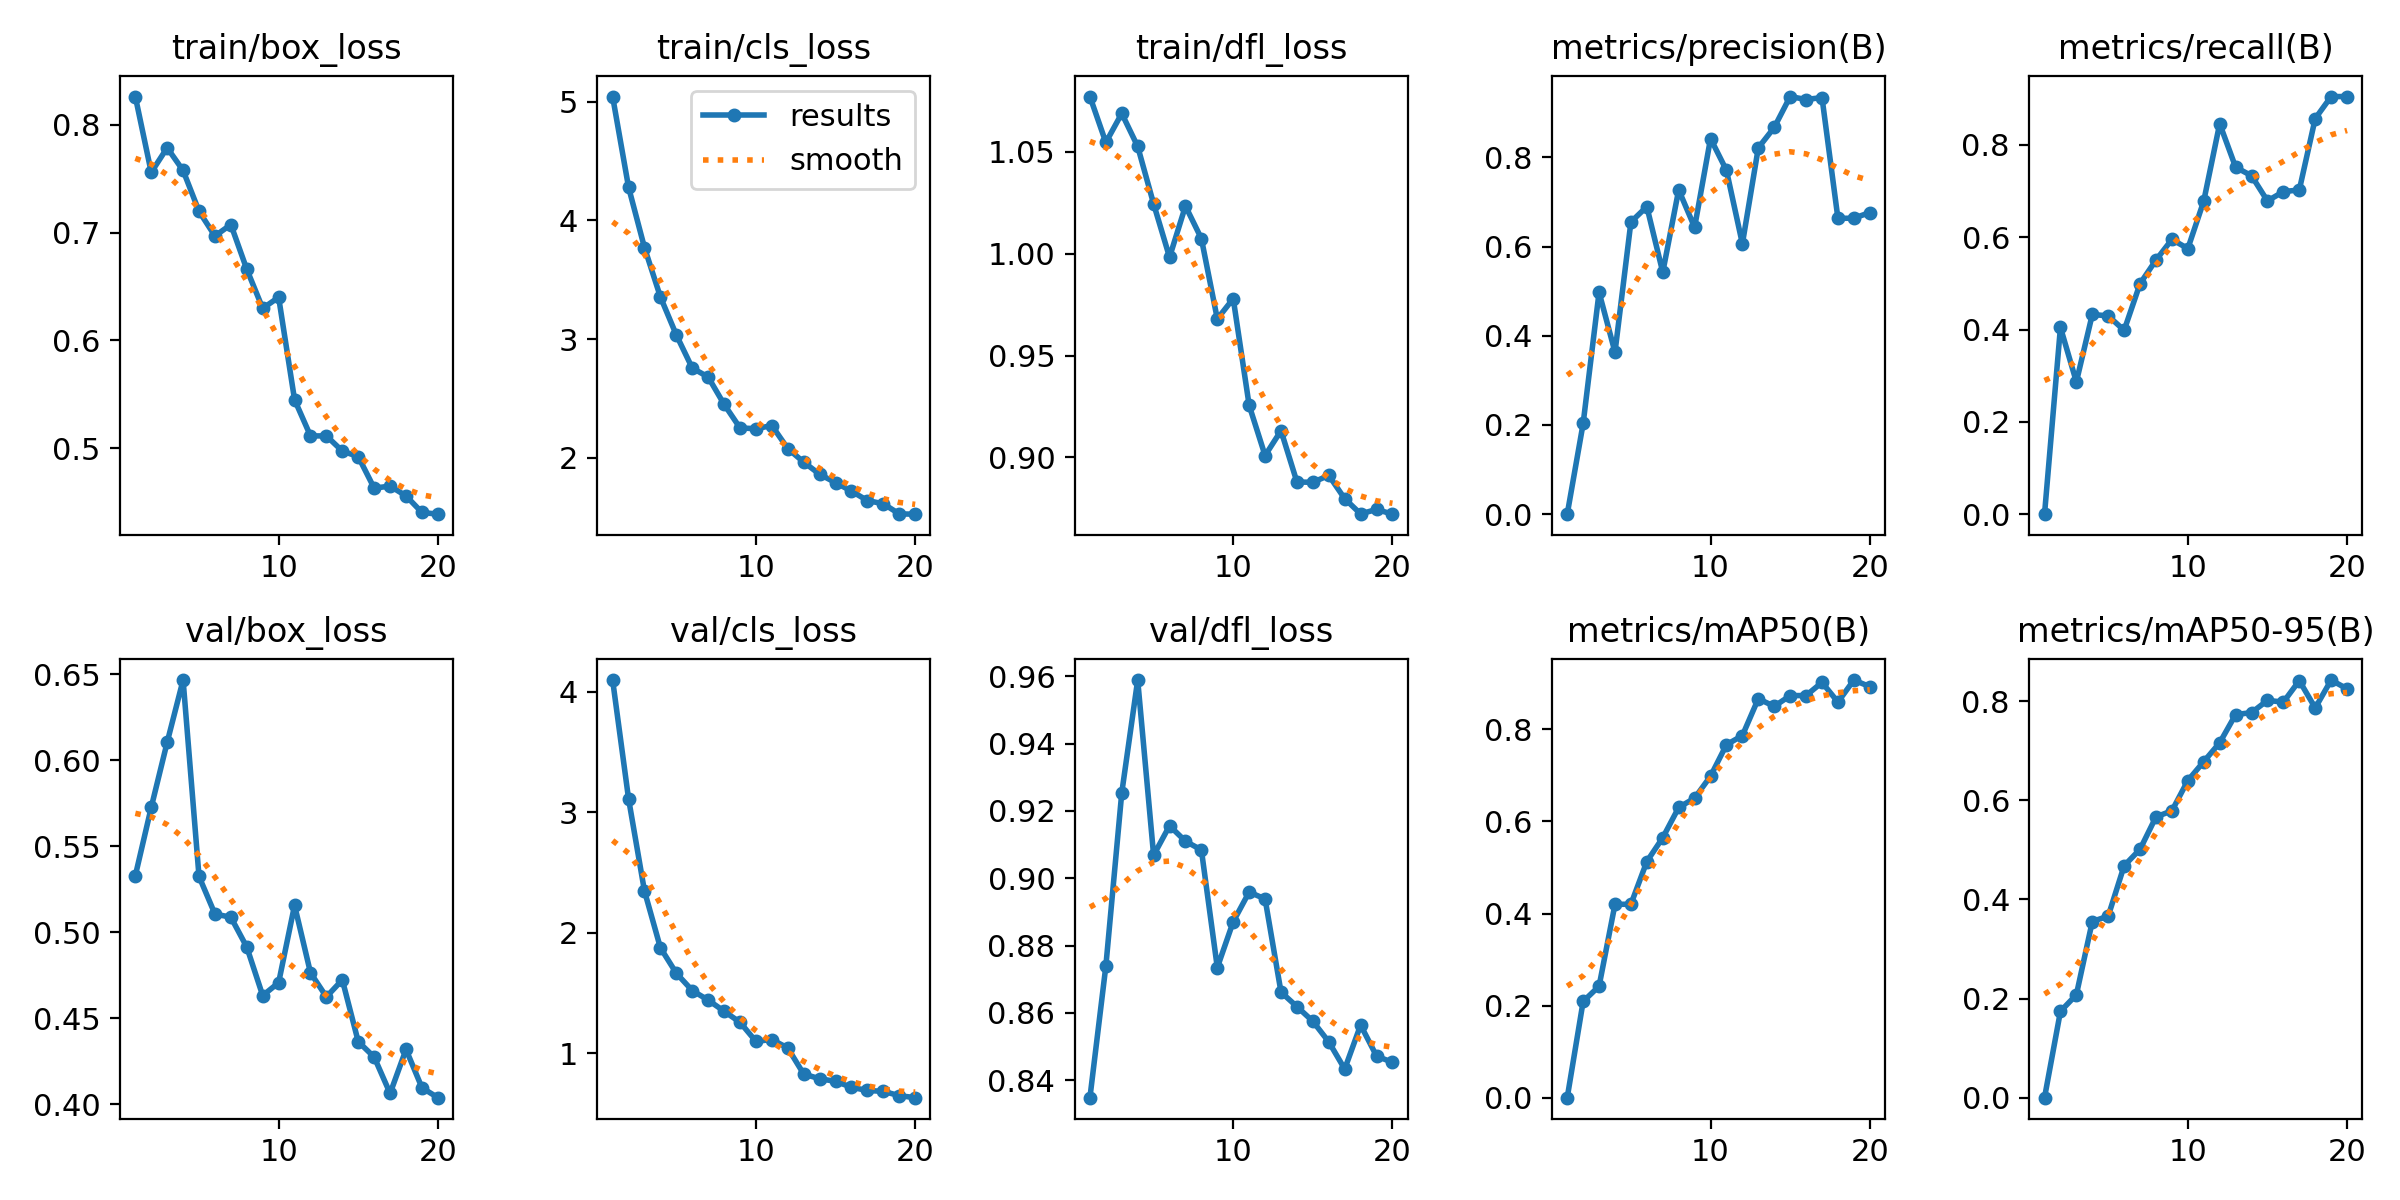

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=1000)

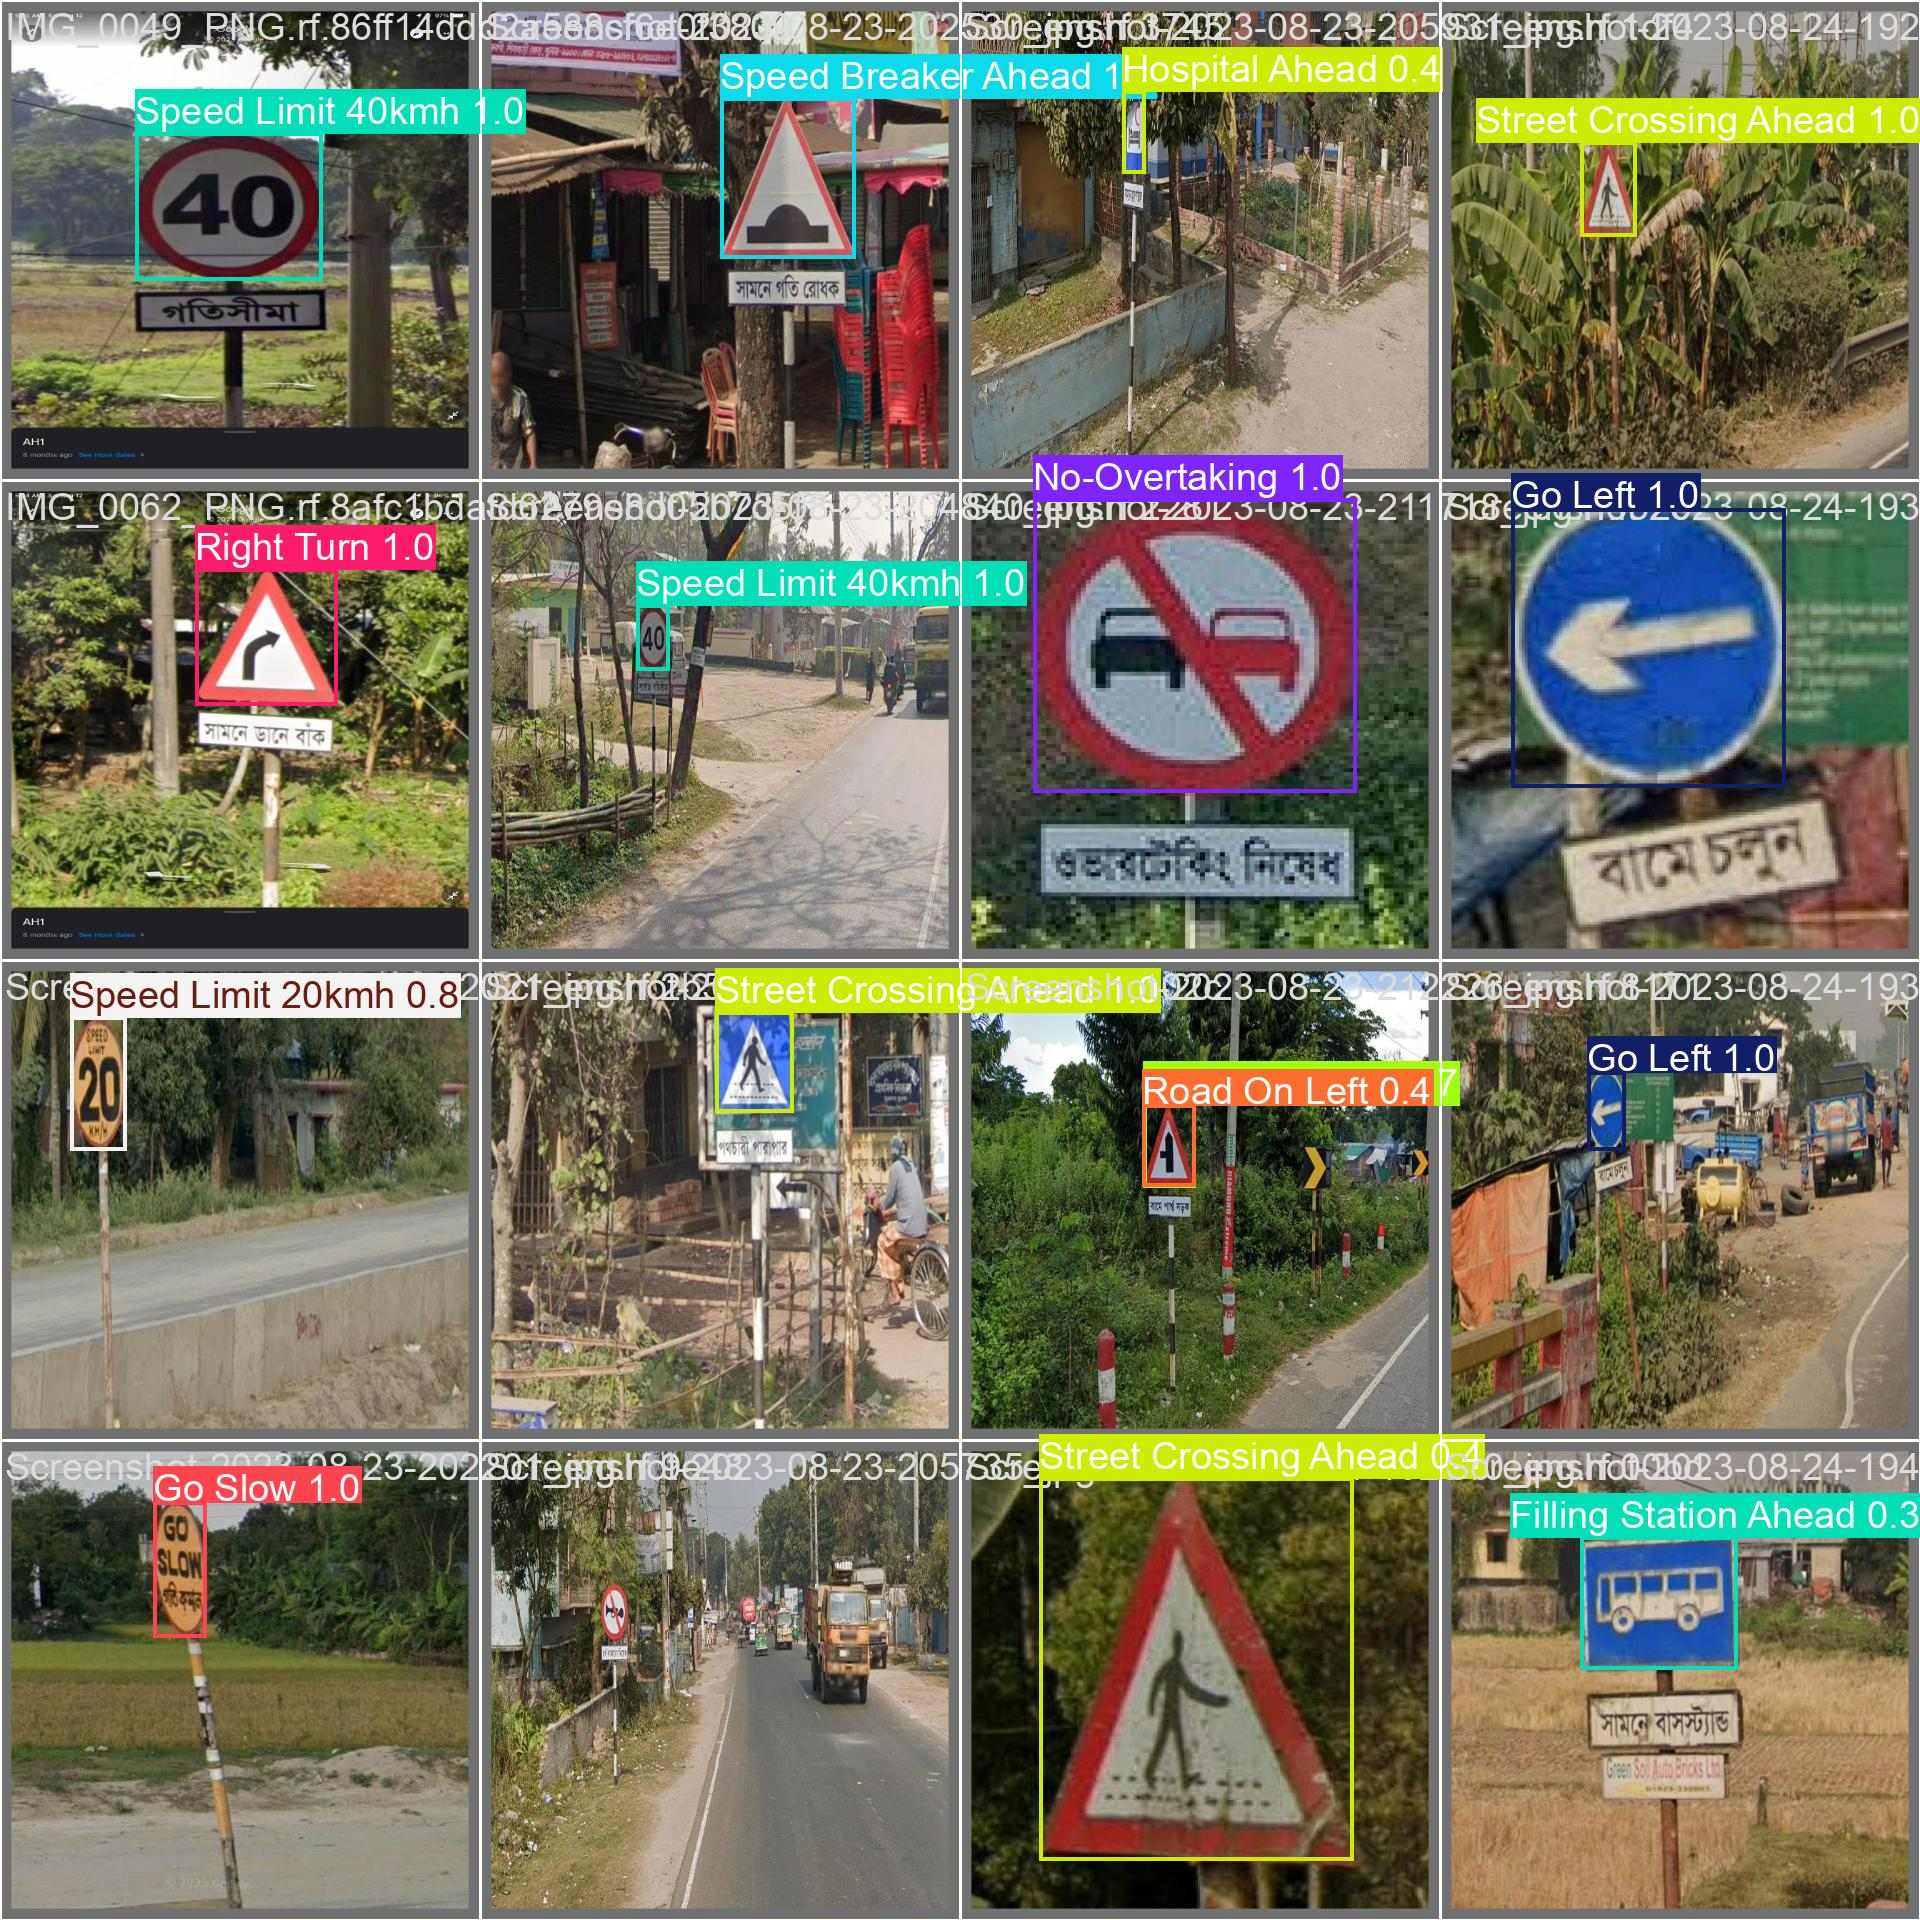

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=1000)

## Validate fine-tuned model

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs
val: Scanning /content/datasets/BD-Road-Sign-Dataset-Creation-1/valid/labels.cache... 46 images, 0 backgrounds, 0 corrupt: 100% 46/46 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 3/3 [00:03<00:00,  1.07s/it]
                   all         46         49      0.664      0.905      0.907      0.834
              Bus Stop          1          1      0.562          1      0.995      0.995
      Crossroads Ahead          2          2      0.717          1      0.995      0.921
               Go Left          2          2      0.696          1      0.995      0.921
               Go Slow          1          1      0.583          1      0.995      0.895
        Hospital Ahead          2          2       0.74        0.5      0.499        0.4
             Left Turn    

## Inference with custom model

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/48 /content/datasets/BD-Road-Sign-Dataset-Creation-1/test/images/IMG_0026_PNG.rf.6a74e0f87552773e23997903c97e1c1a.jpg: 640x640 1 Speed Limit 40kmh, 1 Speed Limit 60kmh, 12.7ms
image 2/48 /content/datasets/BD-Road-Sign-Dataset-Creation-1/test/images/IMG_0055_PNG.rf.0d1459c5e4adc2c1ccee6774f02b7d05.jpg: 640x640 1 Road On Left, 1 Road On Right, 9.3ms
image 3/48 /content/datasets/BD-Road-Sign-Dataset-Creation-1/test/images/IMG_0061_PNG.rf.29e63e4a66d6a6ab29f19e5fb0eecbe4.jpg: 640x640 1 Crossroads Ahead, 1 Right Turn, 8.6ms
image 4/48 /content/datasets/BD-Road-Sign-Dataset-Creation-1/test/images/Screenshot-2023-08-23-201056_jpg.rf.241a949d222a863819a3b1b7f89fa59b.jpg: 640x640 1 Go Slow, 8.3ms
image 5/48 /content/datasets/BD-Road-Sign-Dataset-Creation-1/test/images/Screenshot-2023-08-23-203139_jpg.rf.ae477a6be849df76fa0a

**NOTE:** Let's take a look at few results.

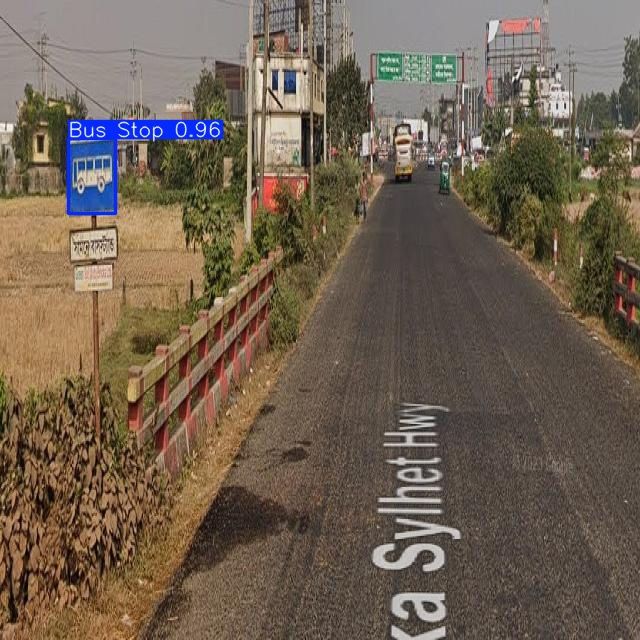

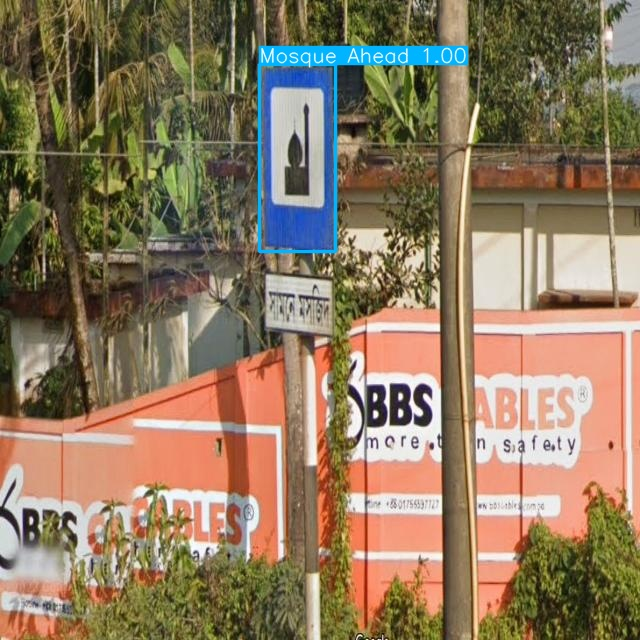

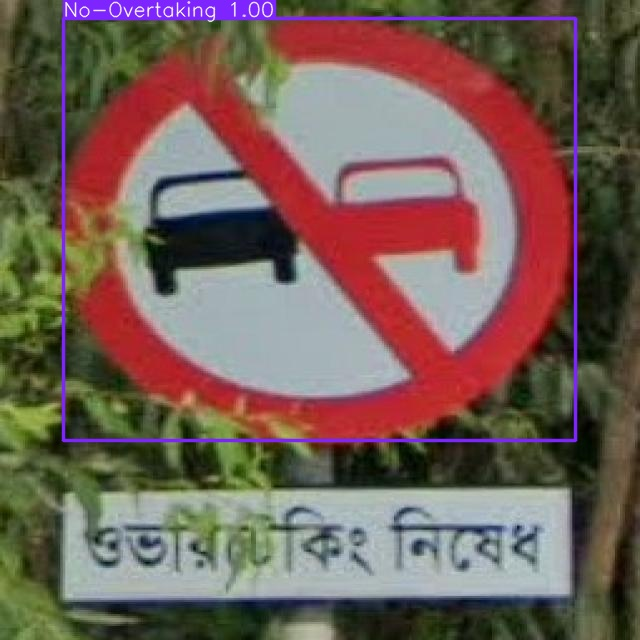

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/IMG_20230701_135150_jpg.rf.4ee22b9fb9fd40b7cde9bde7a986ca67 1.png: 640x640 1 Speed Limit 40kmh, 10.0ms
Speed: 4.0ms preprocess, 10.0ms inference, 181.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict6
💡 Learn more at https://docs.ultralytics.com/modes/predict
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/IMG_20230701_135150_jpg.rf.4ee22b9fb9fd40b7cde9bde7a986ca67 1.png: 640x640 1 Speed Limit 40kmh, 10.3ms
Speed: 3.9ms preprocess, 10.3ms inference, 145.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict7
💡 Learn more at https://docs.ultralytics.com/modes/predict


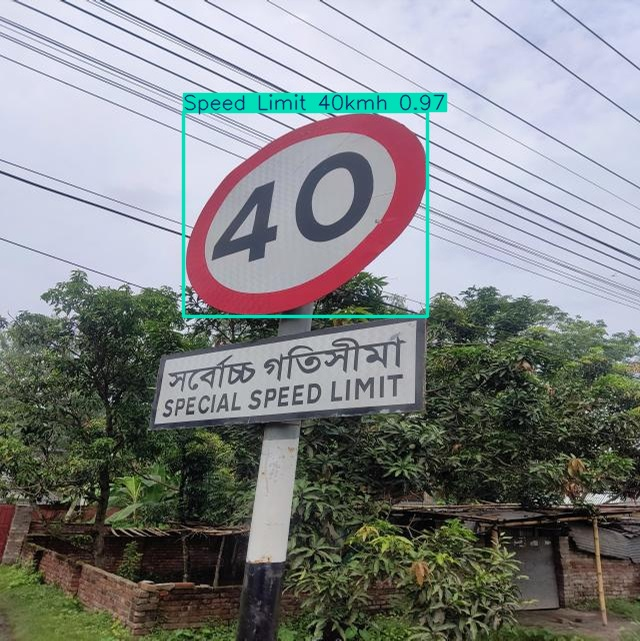

In [ ]:
x = '/content/IMG_20230701_135150_jpg.rf.4ee22b9fb9fd40b7cde9bde7a986ca67 1.png'

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/IMG_20230701_135150_jpg.rf.4ee22b9fb9fd40b7cde9bde7a986ca67 1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/IMG_20230701_135150_jpg.rf.4ee22b9fb9fd40b7cde9bde7a986ca67 1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

# Display the image with predictions
for img in glob.glob(f'{latest_folder}/*.jpg'):
    display(IPyImage(filename=img, width=600))

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/IMG_20230701_135329_jpg.rf.d765d7ec87d371229a74f2312df5f82c 1.png: 640x640 1 Speed Breaker Ahead, 11.7ms
Speed: 3.8ms preprocess, 11.7ms inference, 155.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict8
💡 Learn more at https://docs.ultralytics.com/modes/predict
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/IMG_20230701_135329_jpg.rf.d765d7ec87d371229a74f2312df5f82c 1.png: 640x640 1 Speed Breaker Ahead, 10.0ms
Speed: 3.8ms preprocess, 10.0ms inference, 155.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict9
💡 Learn more at https://docs.ultralytics.com/modes/predict


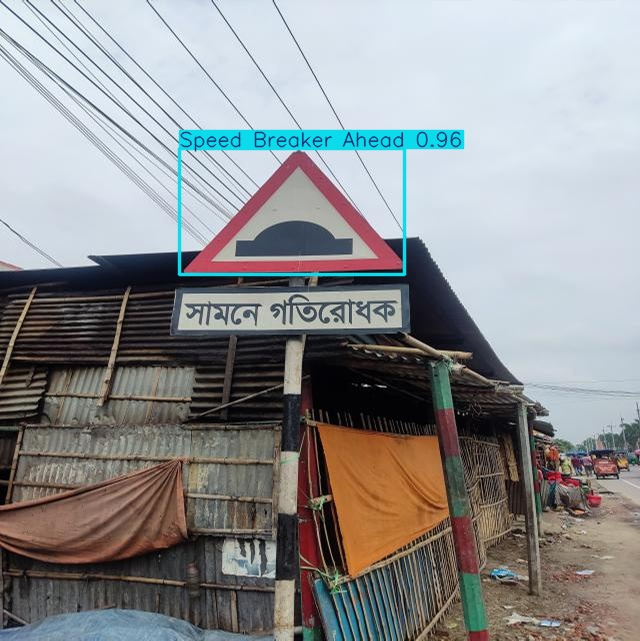

In [ ]:
x = '/content/IMG_20230701_135150_jpg.rf.4ee22b9fb9fd40b7cde9bde7a986ca67 1.png'

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/IMG_20230701_135329_jpg.rf.d765d7ec87d371229a74f2312df5f82c 1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/IMG_20230701_135329_jpg.rf.d765d7ec87d371229a74f2312df5f82c 1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

# Display the image with predictions
for img in glob.glob(f'{latest_folder}/*.jpg'):
    display(IPyImage(filename=img, width=600))

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/Screenshot-2023-08-23-201516_jpg.rf.719b8dd3768ee93d0b22a58f29af6cce 1.png: 640x640 1 Go Slow, 11.3ms
Speed: 5.0ms preprocess, 11.3ms inference, 182.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict10
💡 Learn more at https://docs.ultralytics.com/modes/predict
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/Screenshot-2023-08-23-201516_jpg.rf.719b8dd3768ee93d0b22a58f29af6cce 1.png: 640x640 1 Go Slow, 10.1ms
Speed: 3.8ms preprocess, 10.1ms inference, 182.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict11
💡 Learn more at https://docs.ultralytics.com/modes/predict


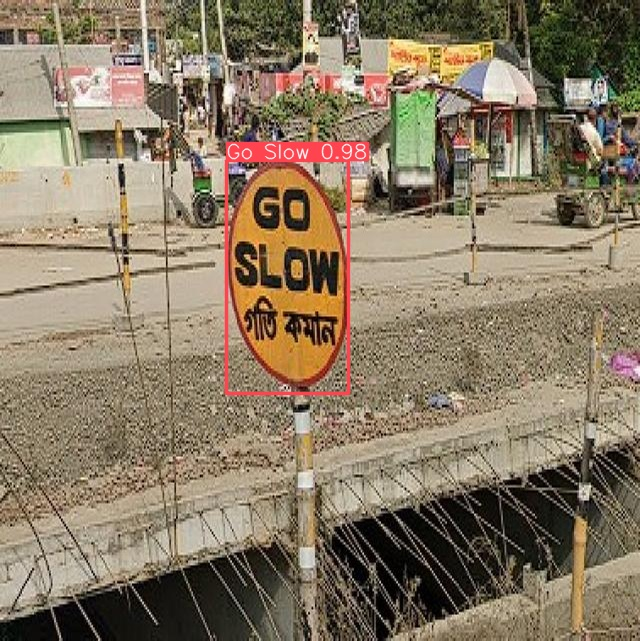

In [ ]:
x = '/content/IMG_20230701_135150_jpg.rf.4ee22b9fb9fd40b7cde9bde7a986ca67 1.png'

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/Screenshot-2023-08-23-201516_jpg.rf.719b8dd3768ee93d0b22a58f29af6cce 1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/Screenshot-2023-08-23-201516_jpg.rf.719b8dd3768ee93d0b22a58f29af6cce 1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

# Display the image with predictions
for img in glob.glob(f'{latest_folder}/*.jpg'):
    display(IPyImage(filename=img, width=600))

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/Screenshot-2023-08-23-204740_jpg.rf.bc5e33a502fbcd3743b5855a33dde8c0 1.png: 640x640 1 Speed Limit 40kmh, 8.9ms
Speed: 3.4ms preprocess, 8.9ms inference, 140.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict12
💡 Learn more at https://docs.ultralytics.com/modes/predict
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/Screenshot-2023-08-23-204740_jpg.rf.bc5e33a502fbcd3743b5855a33dde8c0 1.png: 640x640 1 Speed Limit 40kmh, 8.9ms
Speed: 3.3ms preprocess, 8.9ms inference, 134.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict13
💡 Learn more at https://docs.ultralytics.com/modes/predict


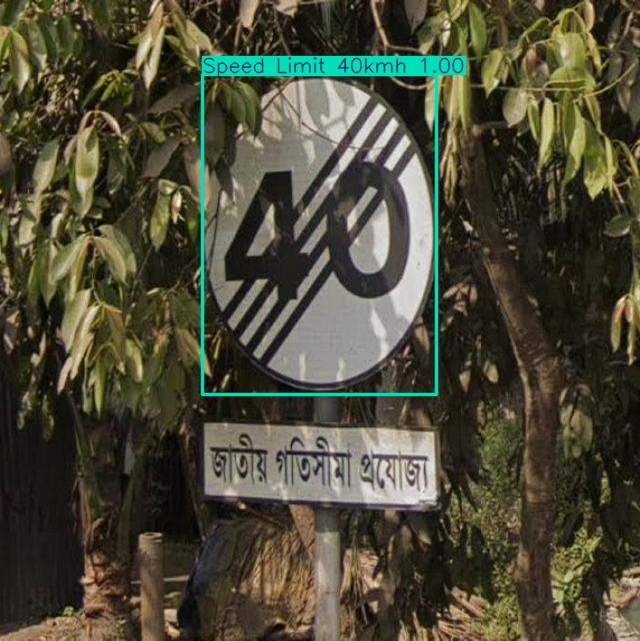

In [ ]:
x = '/content/IMG_20230701_135150_jpg.rf.4ee22b9fb9fd40b7cde9bde7a986ca67 1.png'

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/Screenshot-2023-08-23-204740_jpg.rf.bc5e33a502fbcd3743b5855a33dde8c0 1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/Screenshot-2023-08-23-204740_jpg.rf.bc5e33a502fbcd3743b5855a33dde8c0 1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

# Display the image with predictions
for img in glob.glob(f'{latest_folder}/*.jpg'):
    display(IPyImage(filename=img, width=600))

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/Screenshot-2023-08-23-205810_jpg.rf.1e14915bdbf8db3a27e4f6c340e57bee 1.png: 640x640 1 No Horns, 9.0ms
Speed: 3.8ms preprocess, 9.0ms inference, 150.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict14
💡 Learn more at https://docs.ultralytics.com/modes/predict
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/Screenshot-2023-08-23-205810_jpg.rf.1e14915bdbf8db3a27e4f6c340e57bee 1.png: 640x640 1 No Horns, 17.5ms
Speed: 5.6ms preprocess, 17.5ms inference, 183.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict15
💡 Learn more at https://docs.ultralytics.com/modes/predict


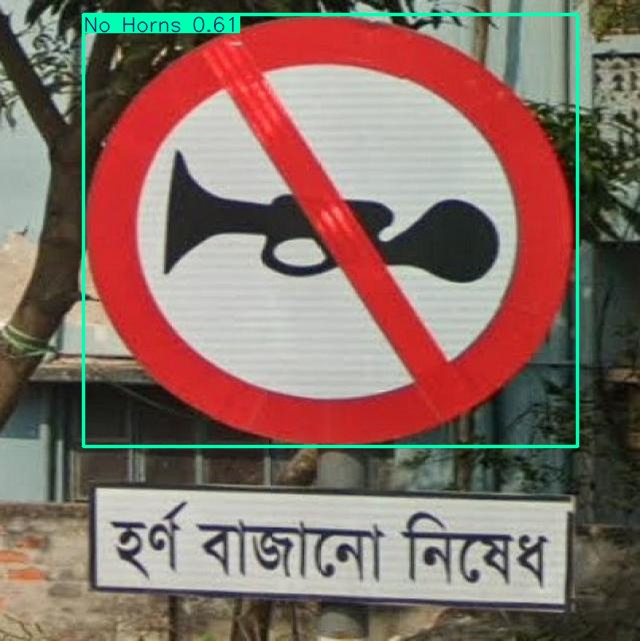

In [ ]:
x = '/content/IMG_20230701_135150_jpg.rf.4ee22b9fb9fd40b7cde9bde7a986ca67 1.png'

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/Screenshot-2023-08-23-205810_jpg.rf.1e14915bdbf8db3a27e4f6c340e57bee 1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/Screenshot-2023-08-23-205810_jpg.rf.1e14915bdbf8db3a27e4f6c340e57bee 1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

# Display the image with predictions
for img in glob.glob(f'{latest_folder}/*.jpg'):
    display(IPyImage(filename=img, width=600))

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/Screenshot-2023-08-23-210058_jpg.rf.f775490915ec4e0767f33aff247769c5 1.png: 640x640 1 Street Crossing Ahead, 14.9ms
Speed: 5.0ms preprocess, 14.9ms inference, 204.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict16
💡 Learn more at https://docs.ultralytics.com/modes/predict
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/Screenshot-2023-08-23-210058_jpg.rf.f775490915ec4e0767f33aff247769c5 1.png: 640x640 1 Street Crossing Ahead, 9.0ms
Speed: 3.6ms preprocess, 9.0ms inference, 135.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict17
💡 Learn more at https://docs.ultralytics.com/modes/predict


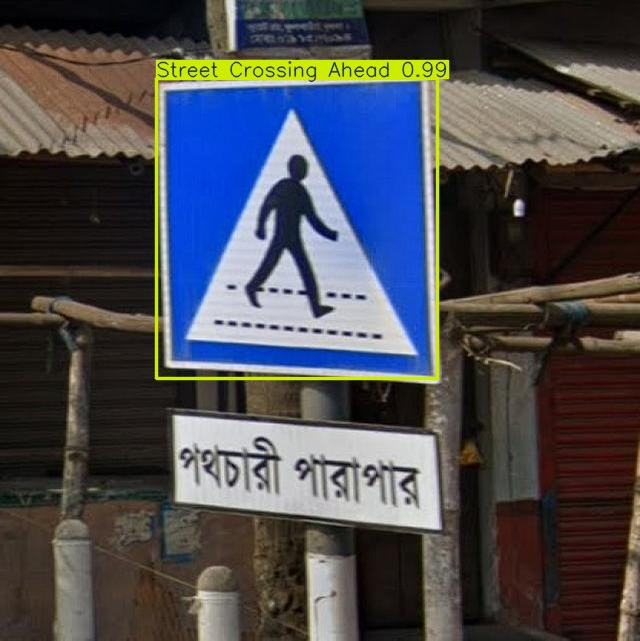

In [ ]:
x = '/content/IMG_20230701_135150_jpg.rf.4ee22b9fb9fd40b7cde9bde7a986ca67 1.png'

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/Screenshot-2023-08-23-210058_jpg.rf.f775490915ec4e0767f33aff247769c5 1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/Screenshot-2023-08-23-210058_jpg.rf.f775490915ec4e0767f33aff247769c5 1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

# Display the image with predictions
for img in glob.glob(f'{latest_folder}/*.jpg'):
    display(IPyImage(filename=img, width=600))

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/Screenshot-2023-08-23-211744_jpg.rf.93ed1c845a40a074586fd7fd282a2f0e 1.png: 640x640 1 No-Overtaking, 10.3ms
Speed: 4.2ms preprocess, 10.3ms inference, 145.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict18
💡 Learn more at https://docs.ultralytics.com/modes/predict
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/Screenshot-2023-08-23-211744_jpg.rf.93ed1c845a40a074586fd7fd282a2f0e 1.png: 640x640 1 No-Overtaking, 8.9ms
Speed: 3.3ms preprocess, 8.9ms inference, 140.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict19
💡 Learn more at https://docs.ultralytics.com/modes/predict


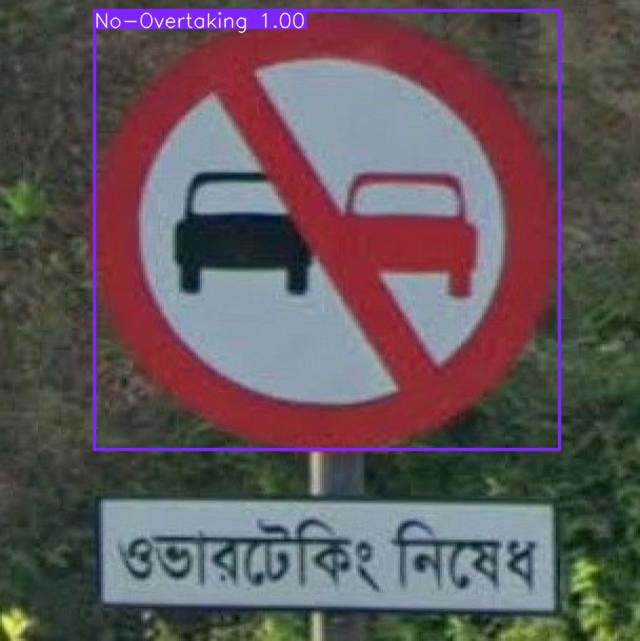

In [ ]:
x = '/content/IMG_20230701_135150_jpg.rf.4ee22b9fb9fd40b7cde9bde7a986ca67 1.png'

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/Screenshot-2023-08-23-211744_jpg.rf.93ed1c845a40a074586fd7fd282a2f0e 1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/Screenshot-2023-08-23-211744_jpg.rf.93ed1c845a40a074586fd7fd282a2f0e 1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

# Display the image with predictions
for img in glob.glob(f'{latest_folder}/*.jpg'):
    display(IPyImage(filename=img, width=600))

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/Screenshot-2023-08-24-191815_jpg.rf.9b796d3c44814773b9898d3db07e43e1.png: 640x640 1 Mosque Ahead, 10.8ms
Speed: 3.0ms preprocess, 10.8ms inference, 178.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict24
💡 Learn more at https://docs.ultralytics.com/modes/predict
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/Screenshot-2023-08-24-191815_jpg.rf.9b796d3c44814773b9898d3db07e43e1.png: 640x640 1 Mosque Ahead, 11.5ms
Speed: 2.9ms preprocess, 11.5ms inference, 173.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict25
💡 Learn more at https://docs.ultralytics.com/modes/predict


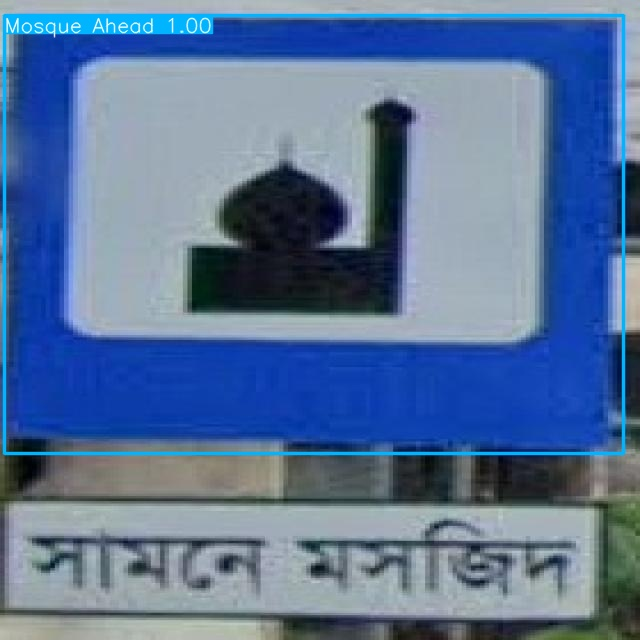

In [ ]:
x = '/content/IMG_20230701_135150_jpg.rf.4ee22b9fb9fd40b7cde9bde7a986ca67 1.png'

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/Screenshot-2023-08-24-191815_jpg.rf.9b796d3c44814773b9898d3db07e43e1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/Screenshot-2023-08-24-191815_jpg.rf.9b796d3c44814773b9898d3db07e43e1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

# Display the image with predictions
for img in glob.glob(f'{latest_folder}/*.jpg'):
    display(IPyImage(filename=img, width=600))

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/images_jpeg.rf.8ba18a4dfb3fbccc8ce9216e68f5e897 1.png: 640x640 1 School Ahead, 13.6ms
Speed: 5.3ms preprocess, 13.6ms inference, 180.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict22
💡 Learn more at https://docs.ultralytics.com/modes/predict
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/images_jpeg.rf.8ba18a4dfb3fbccc8ce9216e68f5e897 1.png: 640x640 1 School Ahead, 9.0ms
Speed: 3.5ms preprocess, 9.0ms inference, 132.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict23
💡 Learn more at https://docs.ultralytics.com/modes/predict


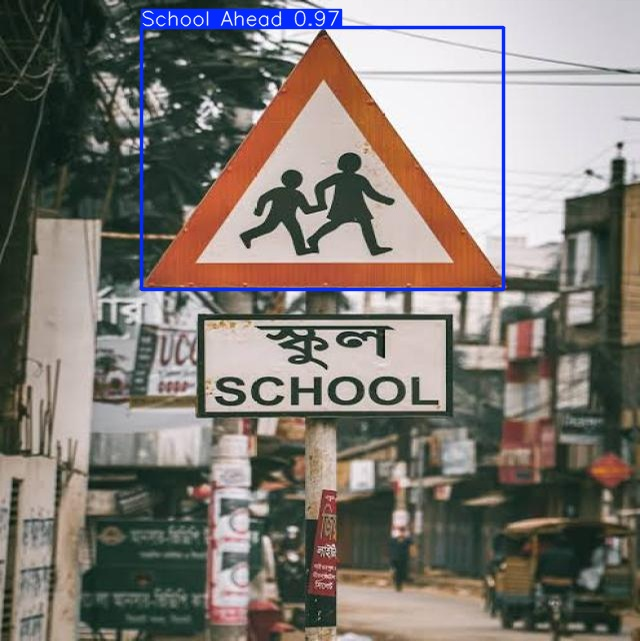

In [ ]:
x = '/content/IMG_20230701_135150_jpg.rf.4ee22b9fb9fd40b7cde9bde7a986ca67 1.png'

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/images_jpeg.rf.8ba18a4dfb3fbccc8ce9216e68f5e897 1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/images_jpeg.rf.8ba18a4dfb3fbccc8ce9216e68f5e897 1.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

# Display the image with predictions
for img in glob.glob(f'{latest_folder}/*.jpg'):
    display(IPyImage(filename=img, width=600))

Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/Dataset3x3.png: 640x640 1 Go Slow, 1 Mosque Ahead, 1 No-Overtaking, 1 Right Turn, 3 Speed Limit 40kmhs, 1 Street Crossing Ahead, 10.8ms
Speed: 8.5ms preprocess, 10.8ms inference, 159.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict4
💡 Learn more at https://docs.ultralytics.com/modes/predict
Ultralytics 8.3.40 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,587,612 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/Dataset3x3.png: 640x640 1 Go Slow, 1 Mosque Ahead, 1 No-Overtaking, 1 Right Turn, 3 Speed Limit 40kmhs, 1 Street Crossing Ahead, 9.7ms
Speed: 5.6ms preprocess, 9.7ms inference, 141.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict5
💡 Learn more at https://doc

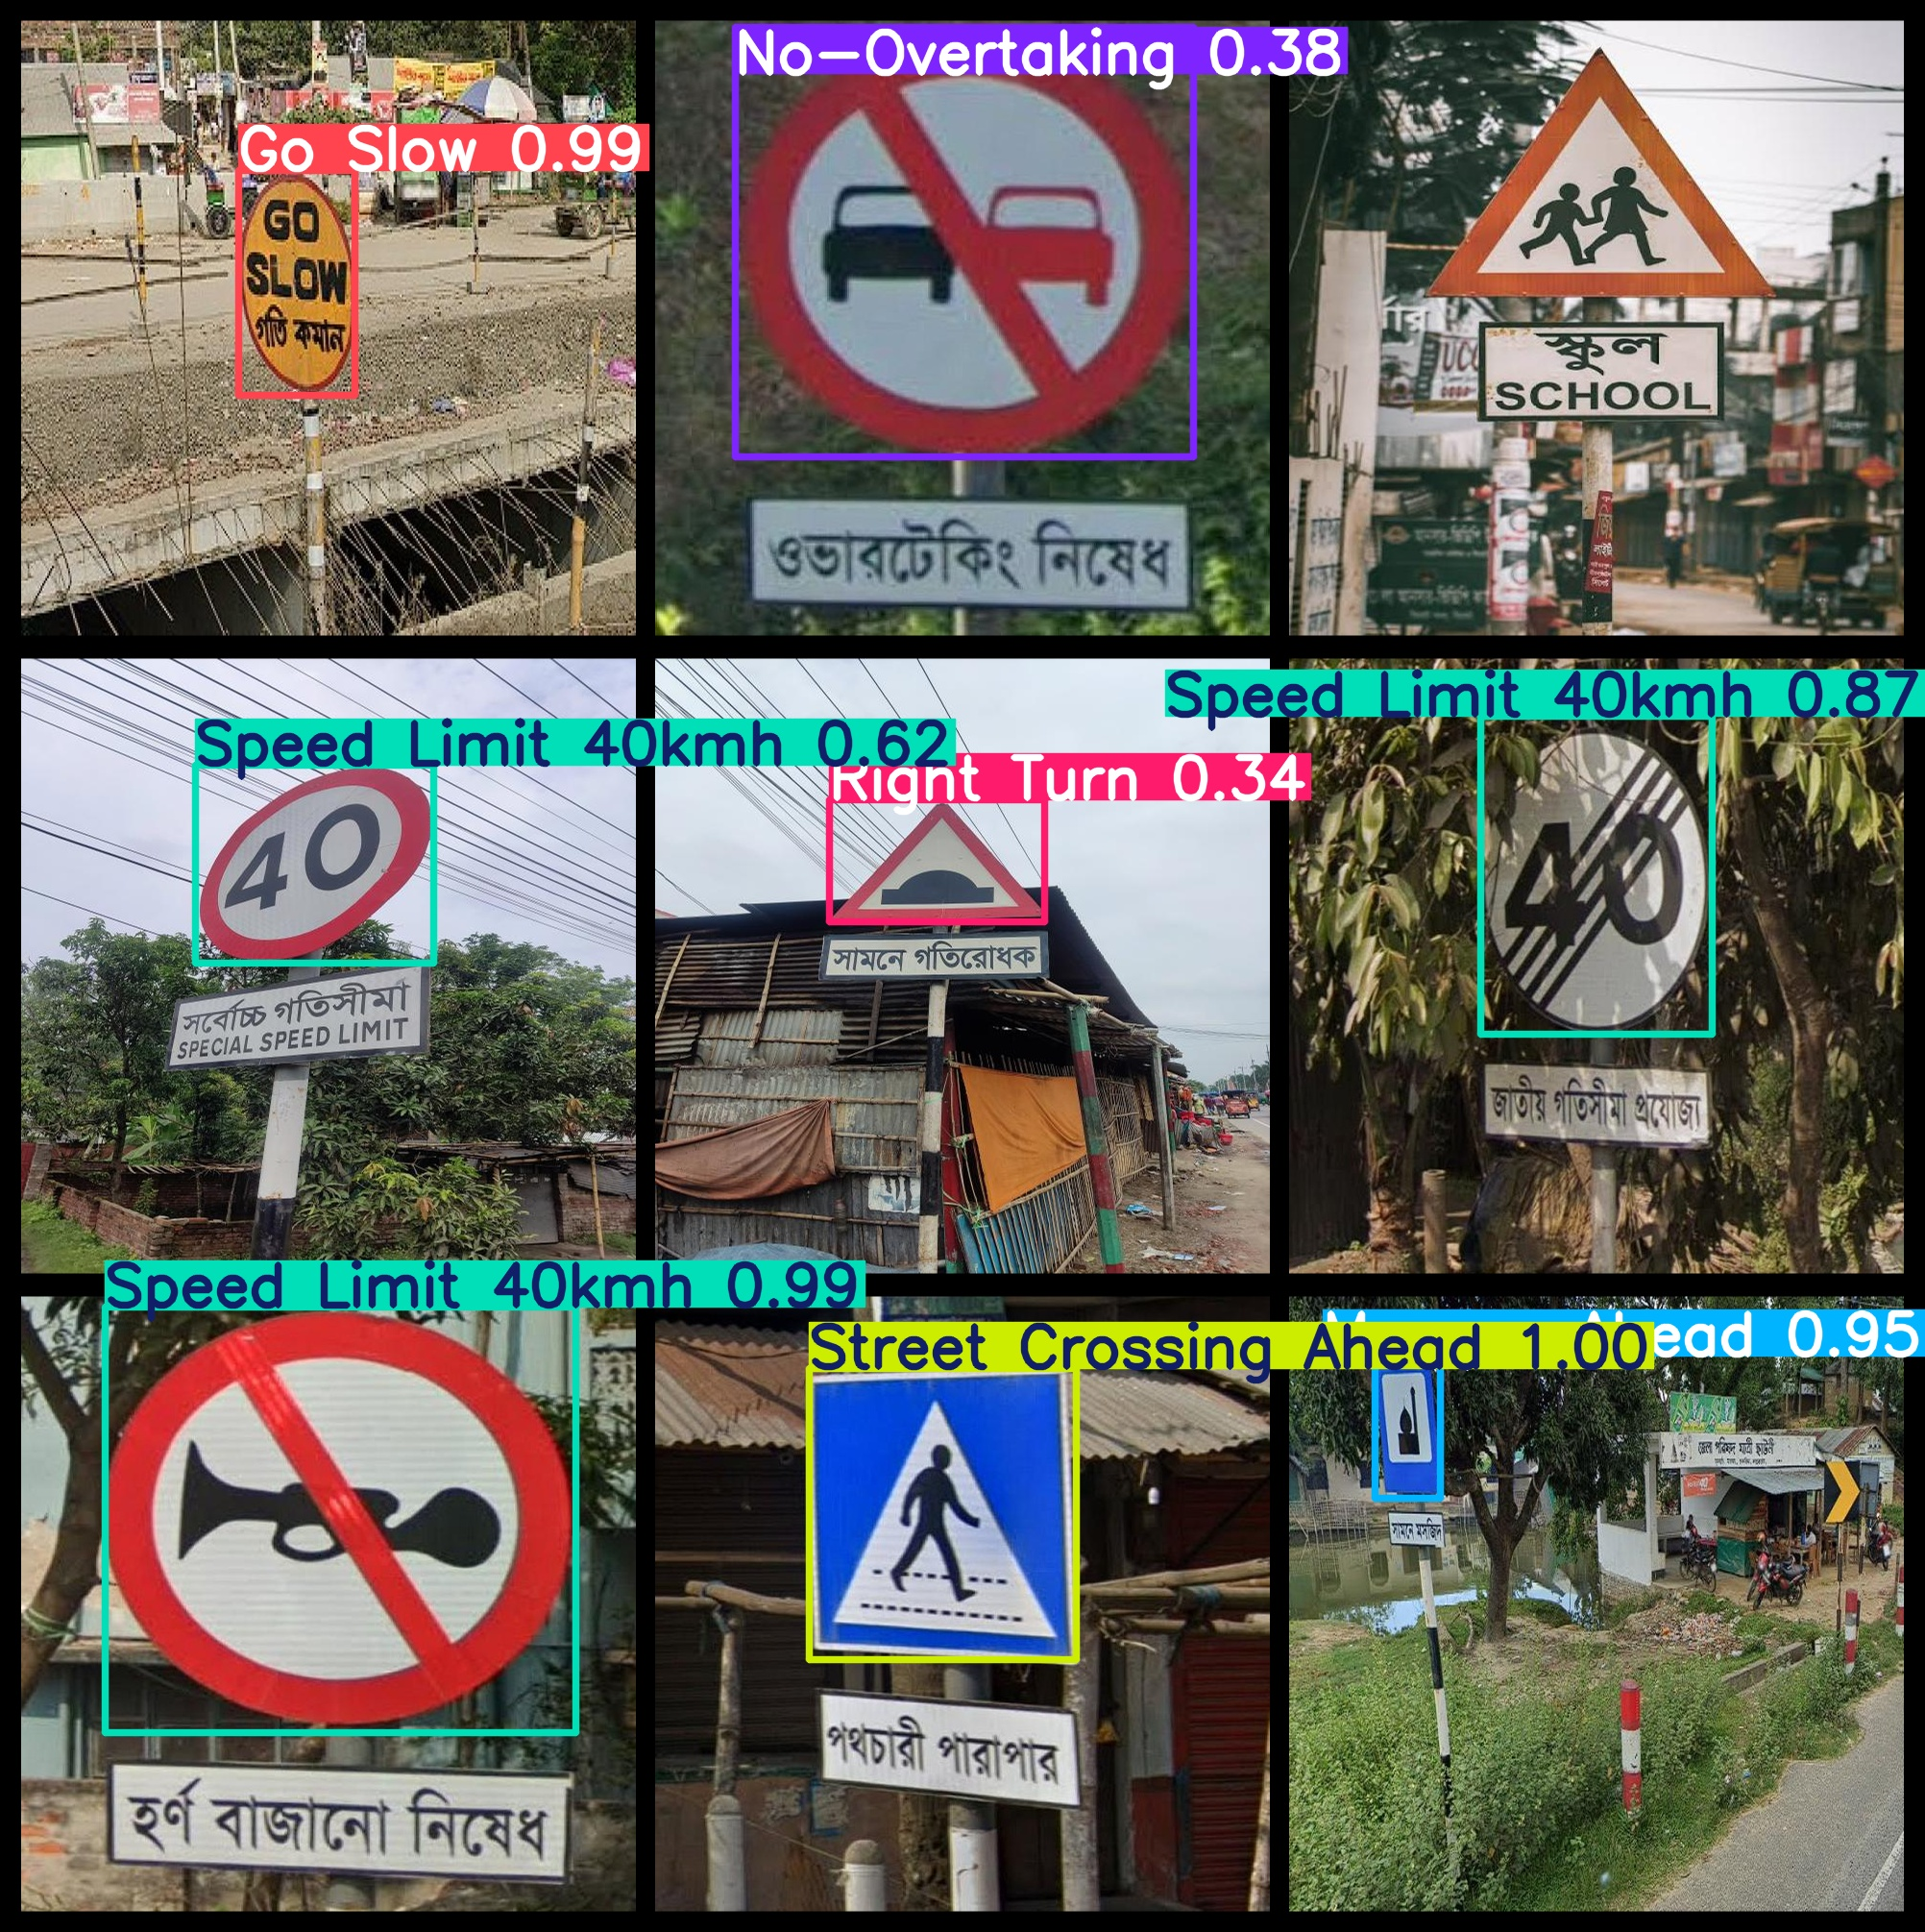

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/Dataset3x3.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source='/content/Dataset3x3.png' save=True

import glob
import os
from IPython.display import Image as IPyImage, display

# Get the latest prediction folder
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)

# Display the image with predictions
for img in glob.glob(f'{latest_folder}/*.jpg'):
    display(IPyImage(filename=img, width=600))

In [ ]:
import time
from google.colab import files

# Step 1: Define path to the model weights
# Corrected path: Assuming training output is in 'runs/detect/train'
model_weights_path = 'runs/detect/train/weights/best.pt'
# If your training output is in 'runs/detect/train2', then keep the original path

# Step 2: Start the timer
start_time = time.time()

# Download the model weights
files.download(model_weights_path)

# Step 3: Calculate the time taken to download
end_time = time.time()
download_time = end_time - start_time

# Print the download time
print(f"Model weights downloaded successfully in {download_time:.2f} seconds.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model weights downloaded successfully in 0.00 seconds.
